In [54]:
import os

! pip install tensorflow==2.4.0

# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

# Set seed for experimental reproducibility
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)

CIRCLES_OS_PATH = 'circles/'
RECTANGLES_OS_PATH = 'rectangles/'
TRIANGLES_OS_PATH = 'triangles/'

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


## Create Shapes (Data Augmentation)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

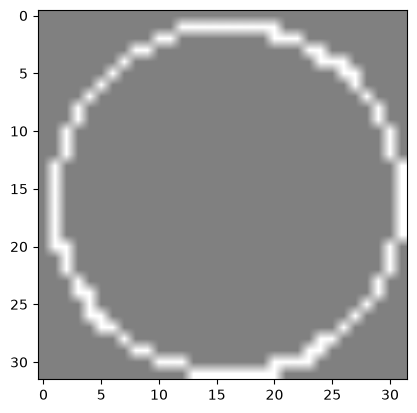

In [58]:
SAMPLES = 1000
WIDTH = 32
HEIGHT = 32

screen = np.zeros((HEIGHT, WIDTH), dtype=np.int8)
np.set_printoptions(threshold=np.inf)

def generate_circle(center_x, center_y, radius):
    current_x = math.cos(0)
    current_y = math.sin(0)
    angle = 0
    while angle <= (math.pi*2):
        index_x = round((current_x*radius)+center_x)
        index_y = round((current_y*radius)+center_y)
        if not(index_x > WIDTH or index_x < 0 or index_y > HEIGHT or index_y < 0):     
            screen[index_x][index_y] = 1
            current_x = math.cos(angle)
            current_y = math.sin(angle)
            angle += 0.05
    
    with open(os.path.join(CIRCLES_OS_PATH, 'test.b'), 'w') as fp:
        pass

    np.savetxt(os.path.join(CIRCLES_OS_PATH, 'test.b'), screen, fmt="%d")        


generate_circle(math.floor(WIDTH/2),math.floor(HEIGHT/2),15)
print(screen)
plt.imshow(screen, interpolation='bilinear', cmap='gray', vmax=abs(screen).max(), vmin=-abs(screen).max())